# 🌾 Crop Recommendation System
### AI/ML Project

## Step 1: Import Libraries

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

print("Libraries imported ✅")

Libraries imported ✅


## Step 2: Load Dataset

In [65]:
df = pd.read_csv("Crop_Recommendation_Cleaned.csv")
print("Shape:", df.shape)
df.head(10)

Shape: (1846, 9)


,Sr. No.,Nitrogen (N),Phosphorus (P),Potassium (K),Temperature (°C),Humidity (%),pH Level,Rainfall (mm),Crop Label
0,1,90,42,43,20.8797,82.0027,6.5030,202.9355,Rice
1,2,85,58,41,21.7705,80.3196,7.0381,226.6555,Rice
2,3,74,35,40,26.4911,80.1584,6.9804,242.8640,Rice
3,4,94,53,40,20.2777,82.8941,5.7186,241.9742,Rice
4,5,89,54,38,24.5159,83.5352,6.6853,230.4462,Rice
5,6,68,58,38,23.2240,83.0332,6.3363,221.2092,Rice
6,7,93,56,36,24.0150,82.0569,6.9844,185.2773,Rice
7,8,94,50,37,25.6659,80.6639,6.9480,209.5870,Rice
8,9,60,48,39,24.2821,80.3003,7.0423,231.0863,Rice
9,10,91,35,39,23.7939,80.4182,6.9709,206.2612,Rice


## Step 3: Data Cleaning

In [66]:
# Drop unnecessary columns
if "Sr. No." in df.columns:
    df.drop(columns=["Sr. No."], inplace=True)

# Check missing values
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Nitrogen (N)        0
Phosphorus (P)      0
Potassium (K)       0
Temperature (°C)    0
Humidity (%)        0
pH Level            0
Rainfall (mm)       0
Crop Label          0
dtype: int64


In [67]:
# Check duplicates
print("Duplicate Rows:", df.duplicated().sum())

# Remove duplicates
df = df.drop_duplicates()
print("After removing duplicates:", df.shape)

Duplicate Rows: 0
After removing duplicates: (1846, 8)


In [68]:
# Check for outliers using IQR
feature_cols = ["Nitrogen (N)", "Phosphorus (P)", "Potassium (K)",
                "Temperature (°C)", "Humidity (%)", "pH Level", "Rainfall (mm)"]

print("Outliers per column (IQR method):")
for col in feature_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(f"  {col}: {len(outliers)} outliers")

Outliers per column (IQR method):
  Nitrogen (N): 0 outliers
  Phosphorus (P): 0 outliers
  Potassium (K): 26 outliers
  Temperature (°C): 4 outliers
  Humidity (%): 0 outliers
  pH Level: 10 outliers
  Rainfall (mm): 18 outliers


In [69]:
# Remove outliers
before = len(df)
for col in feature_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    df = df[(df[col] >= Q1 - 1.5*IQR) & (df[col] <= Q3 + 1.5*IQR)]

df = df.reset_index(drop=True)
print(f"Rows before: {before} | Rows after: {len(df)} | Removed: {before - len(df)}")
print("Data cleaning complete ✅")

Rows before: 1846 | Rows after: 1772 | Removed: 74
Data cleaning complete ✅


## Step 5: Preprocessing

In [70]:
# Separate features and target
X = df[feature_cols]
y = df["Crop Label"]

# Encode crop labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Normalize features
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

print("Features shape:", X_scaled.shape)
print("Total classes :", len(le.classes_))
print("Crops:", list(le.classes_))

Features shape: (1772, 7)
Total classes : 20
Crops: ['Banana', 'Blackgram', 'Chickpea', 'Coconut', 'Coffee', 'Cotton', 'Jute', 'Kidneybeans', 'Lentil', 'Maize', 'Mango', 'Mothbeans', 'Mungbean', 'Muskmelon', 'Orange', 'Papaya', 'Pigeonpeas', 'Pomegranate', 'Rice', 'Watermelon']


## Step 6: Train / Test Split

In [71]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])

Training samples: 1417
Testing samples : 355


## Step 7: Train Models

In [72]:
# Model 1 - Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_acc  = accuracy_score(y_test, rf_pred)
print(f"Random Forest Accuracy: {rf_acc*100:.2f}%")

Random Forest Accuracy: 99.44%


In [73]:
# Model 2 - Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
dt_acc  = accuracy_score(y_test, dt_pred)
print(f"Decision Tree Accuracy: {dt_acc*100:.2f}%")

Decision Tree Accuracy: 99.15%


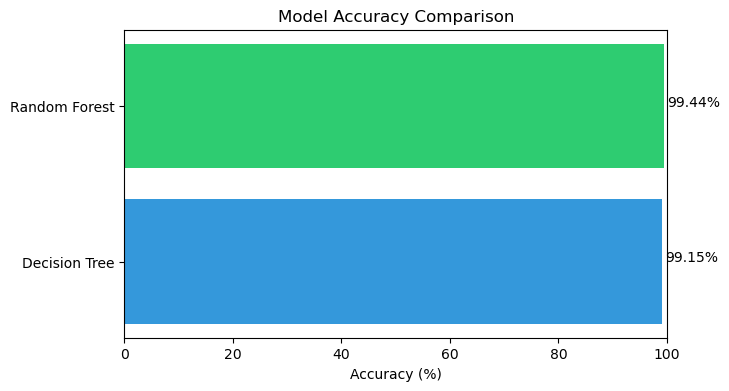

In [74]:
models = ["Decision Tree", "Random Forest"]
accuracies = [dt_acc*100, rf_acc*100]

plt.figure(figsize=(7,4))
plt.barh(models, accuracies, color=["#3498db", "#2ecc71"])

plt.xlabel("Accuracy (%)")
plt.title("Model Accuracy Comparison")
plt.xlim(0, 100)

for i, v in enumerate(accuracies):
    plt.text(v+0.5, i, f"{v:.2f}%")

plt.show()

## Step 8: Confusion Matrix

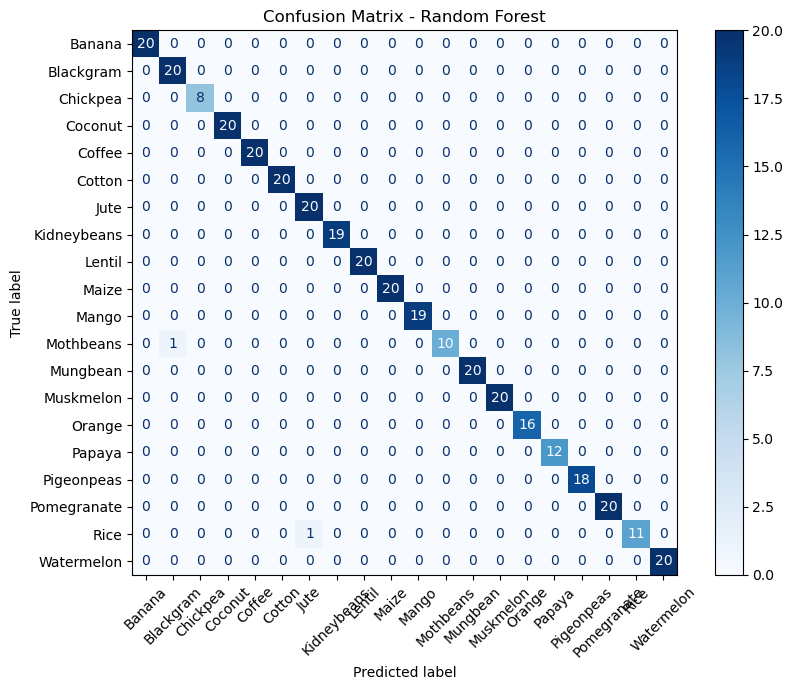

In [75]:
# Random Forest Confusion Matrix
fig, ax = plt.subplots(figsize=(9, 7))
cm = confusion_matrix(y_test, rf_pred)
ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(ax=ax, cmap="Blues", xticks_rotation=45)
ax.set_title("Confusion Matrix - Random Forest")
plt.tight_layout()
plt.show()

## Step 9: Classification Report

In [76]:
print("Random Forest Classification Report:")
print(classification_report(y_test, rf_pred, target_names=le.classes_))

Random Forest Classification Report:
              precision    recall  f1-score   support

      Banana       1.00      1.00      1.00        20
   Blackgram       0.95      1.00      0.98        20
    Chickpea       1.00      1.00      1.00         8
     Coconut       1.00      1.00      1.00        20
      Coffee       1.00      1.00      1.00        20
      Cotton       1.00      1.00      1.00        20
        Jute       0.95      1.00      0.98        20
 Kidneybeans       1.00      1.00      1.00        19
      Lentil       1.00      1.00      1.00        20
       Maize       1.00      1.00      1.00        20
       Mango       1.00      1.00      1.00        19
   Mothbeans       1.00      0.91      0.95        11
    Mungbean       1.00      1.00      1.00        20
   Muskmelon       1.00      1.00      1.00        20
      Orange       1.00      1.00      1.00        16
      Papaya       1.00      1.00      1.00        12
  Pigeonpeas       1.00      1.00      1.00 

In [77]:
feature_cols = ["Nitrogen (N)", "Phosphorus (P)", "Potassium (K)",
                "Temperature (°C)", "Humidity (%)", "pH Level", "Rainfall (mm)"]

# Change these values to test
N, P, K, Temp, Humidity, pH, Rainfall = 90, 42, 43, 21.0, 82.0, 6.5, 202.9

input_data = scaler.transform([[N, P, K, Temp, Humidity, pH, Rainfall]])
prediction = rf.predict(input_data)
crop = le.inverse_transform(prediction)[0]

print(f"N={N}, P={P}, K={K}, Temp={Temp}, Humidity={Humidity}, pH={pH}, Rainfall={Rainfall}")
print(f"Recommended Crop: 🌾 {crop}")

N=90, P=42, K=43, Temp=21.0, Humidity=82.0, pH=6.5, Rainfall=202.9
Recommended Crop: 🌾 Rice


In [84]:
import joblib

joblib.dump(rf, "crop_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(le, "label_encoder.pkl")

print("Model Saved Successfully")

Model Saved Successfully
